# 23 — Los experimentos que quedan

Diez experimentos corridos en su version chica, alineados con el plan maestro del
1 de agosto. E1 a E5 atacan el diseno del objetivo; B1 a B3 son bloqueadores del
paper; R1 y R2 son las dos tareas de rama B que llevaban sin correrse desde el
plan del 27 de julio.

Nomenclatura del plan, usada en todo el notebook. **S_0** es el scorer miope,
P(R=0|H) por la utilidad no acreditada del pool. **Phi_2^cov** es el potencial de
cubierta, que es la V(T) propuesta en sesion. **phi_virgin CBS** es el potencial
cover–binary-search, realizable bajo presupuesto. Tres regimenes, nombrados
completos siempre: **estatico** (el diseno se fija antes de ver nada), **dinamico
binario** (adaptativo, la prueba dice 0 contra al menos 1) y **dinamico
aumentado** (adaptativo, la prueba devuelve el conteo).

Modelo normativo: strict hard clearing, gate G0. Z_i = 1 quiere decir activo;
q_i = P(Z_i = 0) es la probabilidad de estar sano. La variante deductiva es un
modelo distinto y nombrado, y sus numeros no se mezclan con estos.

Regla de desempate congelada del plan: mayor score, luego menor tamano, luego
menor mascara. Los selectores escritos en este notebook (R1 y R2) la implementan
en la funcion `desempate`. Las rutinas de `laminar_benchmarks` que se reusan sin
modificar traen su propia regla congelada, mayor score y luego menor mascara, y
esa diferencia se declara aqui en vez de silenciarse.

Cada afirmacion lleva etiqueta de estatus y cada numero se regenera aqui; nada
escrito a mano.

Correspondencia con el plan: E1 verifica las dos obstrucciones de S2 (A-M11a y
A-M11b); E2 recorre la taxonomia de potenciales; E3 aporta el testigo directo que
pide C5, insumo de A-M17; B1 es la celda dinamico-binaria de §18 (A-M15), que
resuelve C4; B2 fija el ancla del acid test de §16; R1 y R2 alimentan el
falsificador de §17.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

import ast, csv, math, itertools, pathlib, random
from functools import lru_cache
import numpy as np
import matplotlib.pyplot as plt

from augmented.laminar_tables import subset_pmf_cache, subpool_tensor
from augmented.laminar_benchmarks import (
    ExactPolicyEvaluator,
    balanced_laminar_library,
    dynamic_augmented_value,
    greedy_laminar_value,
    rollout_laminar_value,
    static_greedy_value,
)
from augmented.classical_solver import solve_classical_dynamic

RAIZ = pathlib.Path(os.path.abspath('')).parent      # .../augmented

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

print('listo')

listo


## E1. Las dos obstrucciones de S2

Imaginense un pool de cuatro personas donde el conteo sale 3. No cobraron nada,
pero ahora saben que hay exactamente un sano ahi adentro y cada uno tiene
posterior 1/4 de serlo, asi que la utilidad localizada es 4 por u por 1/4.
Ese numero es V(R); promediado sobre los conteos posibles, da la V(T) que se
propuso como objetivo, y que en el vocabulario del plan es el potencial de
cubierta Phi_2^cov.

**La afirmacion [VERIFICADO n<=6].** Confirmacion computacional de las dos
obstrucciones que el plan atribuye a S2. Primera, la de tower: V(R) es lineal en
las posteriores, asi que al promediar sobre R queda la utilidad esperada del pool
bajo las priors y el score no ve la informatividad de la prueba. Segunda, la de
martingala: al subdividir un pool ya observado el potencial no cambia en
esperanza, asi que nunca premia extraer.

In [2]:
def V_de_R(p, u, R):
    '''V(R): utilidad localizada en el pool dado el conteo observado R.'''
    tensor = subpool_tensor(p, R)
    m = len(p)
    return sum(u[i] * tensor[1 << i][0] for i in range(m))


def V_de_T(p, u):
    '''Promedio de V(R) sobre los conteos posibles del pool.'''
    pmf = subset_pmf_cache(p)[(1 << len(p)) - 1]
    return sum(pmf[R] * V_de_R(p, u, R) for R in range(len(p) + 1))


def V_tras_subdividir(p, u, R, S):
    '''Valor esperado del potencial despues de partir el pool probando S.

    Al observar el conteo de S, el pool se parte en dos atomos con conteos que
    suman R. El potencial de cubierta es la suma de los dos.
    '''
    m = len(p)
    dentro = [i for i in range(m) if (S >> i) & 1]
    fuera = [i for i in range(m) if not (S >> i) & 1]
    tensor = subpool_tensor(p, R)
    total = 0.0
    for r in range(len(tensor[S])):
        peso = tensor[S][r]
        if peso <= 0.0:
            continue
        t_dentro = subpool_tensor([p[i] for i in dentro], r) if dentro else None
        t_fuera = subpool_tensor([p[i] for i in fuera], R - r) if fuera else None
        v = 0.0
        for j, i in enumerate(dentro):
            v += u[i] * t_dentro[1 << j][0]
        for j, i in enumerate(fuera):
            v += u[i] * t_fuera[1 << j][0]
        total += peso * v
    return total


rng = np.random.default_rng(23)
peor_tower, peor_mart = 0.0, 0.0
for _ in range(200):
    m = int(rng.integers(2, 7))
    p = rng.uniform(0.05, 0.95, size=m)
    u = rng.uniform(0.5, 3.0, size=m)
    # A-M11a, tower: el incremento de un pool virgen es la utilidad prior.
    peor_tower = max(peor_tower, abs(V_de_T(p, u) - float(np.sum(u * (1.0 - p)))))
    # A-M11b, martingala: subdividir no cambia el potencial en esperanza.
    R = int(rng.integers(1, m))
    S = int(rng.integers(1, (1 << m) - 1))
    peor_mart = max(peor_mart, abs(V_tras_subdividir(p, u, R, S) - V_de_R(p, u, R)))

assert peor_tower < 1e-12, peor_tower
assert peor_mart < 1e-12, peor_mart
print('200 pools aleatorios de 2 a 6 personas')
print(f'tower     : |V(T) - suma u_i*(1-p_i)|            max {peor_tower:.2e}')
print(f'martingala: |V tras subdividir - V(R) antes|     max {peor_mart:.2e}')

200 pools aleatorios de 2 a 6 personas
tower     : |V(T) - suma u_i*(1-p_i)|            max 1.78e-15
martingala: |V tras subdividir - V(R) antes|     max 3.55e-15


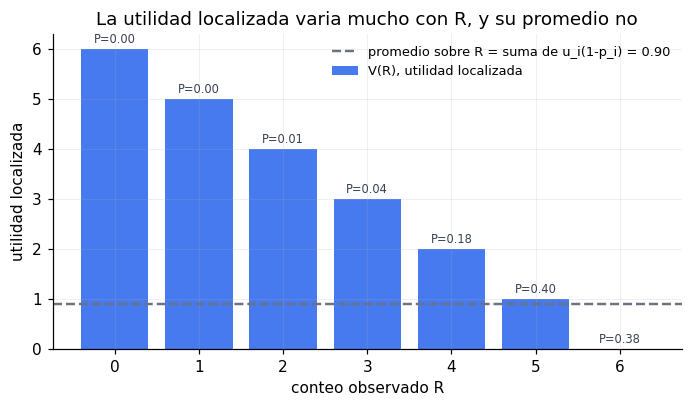

In [3]:
p_ej = np.full(6, 0.85)          # prevalencia alta: 15% de probabilidad de estar sano
u_ej = np.ones(6)
pmf_ej = subset_pmf_cache(p_ej)[(1 << 6) - 1]
Vs = [V_de_R(p_ej, u_ej, R) for R in range(7)]
prior = float(np.sum(u_ej * (1.0 - p_ej)))

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.bar(range(7), Vs, color=AZUL, alpha=0.85, label='V(R), utilidad localizada')
ax.axhline(prior, color=GRIS, ls='--', lw=1.6,
           label=f'promedio sobre R = suma de u_i(1-p_i) = {prior:.2f}')
for R, (v, w) in enumerate(zip(Vs, pmf_ej)):
    ax.annotate(f'P={w:.2f}', (R, v), textcoords='offset points',
                xytext=(0, 4), ha='center', fontsize=7.5, color=TINTA)
ax.set_xlabel('conteo observado R')
ax.set_ylabel('utilidad localizada')
ax.set_title('La utilidad localizada varia mucho con R, y su promedio no')
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
plt.show()

**Lectura.** V(R) va de 6 a 0 segun el conteo, o sea que la variacion es real y
grande. Pero los conteos improbables son justo los de V(R) alto, y al promediar
queda exactamente la utilidad esperada del pool bajo las priors.

Las dos obstrucciones se leen mejor juntas, y la consecuencia es doble en vez de
solo negativa. Por tower, el score de un pool virgen es la suma de u_i q_i, o sea
que crece con el tamano: el objetivo **si resuelve el bootstrap**, porque elige el
pool maximo, que es el primer paso grande que S_0 nunca da. Por martingala,
subdividir un pool ya observado no cambia el potencial en esperanza: el objetivo
**pierde la extraccion**, porque nunca prefiere volver sobre lo que ya vio.

Esa es la moraleja que el plan saca de ahi: el potencial tiene que ser realizable
bajo presupuesto. El bienestar inmediato S_0, en cambio, no se colapsa, es
P(R=0) por la utilidad no acreditada del pool, pero tiene el defecto simetrico de
no dar nunca el primer paso.

**Para discutir.** El valor de la informacion necesita convexidad y V(R) es
lineal. Entre reemplazar la suma por un maximo, descontar por las pruebas que
cuesta extraer, o usar el peor caso del grupo, cual conserva mejor la intuicion
original de premiar la utilidad localizada?

## E2. Que objetivo de un paso si escoge el pool grande

Hagan de cuenta que tienen 11 pruebas, grupos de hasta 1024 personas, todos con
la misma utilidad y con probabilidad 0.001 de estar sanos. Bajo strict hard
clearing la jugada realizable mas grande es un pool de 512: una prueba para
abrirlo, nueve de busqueda binaria y una que acredita. La pregunta es que
objetivo de un solo paso escoge ese primer pool.

**La afirmacion [DEMOSTRADO, algebra elemental].** La utilidad inmediata y el promedio del maximo prefieren la
prueba individual. Los otros tres crecen con el pool, pero solo la utilidad
extraible crece por la razon correcta: mide lo que el binary search si cobra.

In [4]:
q, u, B = 0.001, 1.0, 11
gs = np.array([2 ** k for k in range(0, 11)])          # 1 .. 1024


def inmediato(g):        # utilidad cobrada ya: todos sanos
    return g * u * q ** g

def V_lineal(g):         # la V(T) de E1
    return g * u * q

def V_maximo(g):         # promedio del mejor u_i*q_i(R) del grupo
    return u * q         # con perfiles identicos, E[(g-R)/g] = q

def V_descontado(g):     # utilidad localizada por prueba que cuesta extraerla
    return g * u * q / (1.0 + math.log2(g))

def V_extraible(g):      # phi_virgin CBS, con el test acreditador reservado
    # strict hard clearing: raiz + busqueda binaria + prueba que acredita.
    alcanza = 1 + math.ceil(math.log2(g)) + 1 <= B
    return u * (1.0 - (1.0 - q) ** g) * (1.0 if alcanza else 0.0)


objetivos = {'S_0 (utilidad inmediata)': inmediato, 'Phi_2^cov (E1)': V_lineal,
             'maximo del grupo': V_maximo, 'descontada por log g': V_descontado,
             'phi_virgin CBS': V_extraible}
curvas = {k: np.array([f(int(g)) for g in gs]) for k, f in objetivos.items()}

assert gs[int(np.argmax(curvas['S_0 (utilidad inmediata)']))] == 1
assert gs[int(np.argmax(curvas['phi_virgin CBS']))] == 512
for k, c in curvas.items():
    print(f'{k:26s} argmax en g = {gs[int(np.argmax(c))]:5d}   valor {c.max():.4f}')

S_0 (utilidad inmediata)   argmax en g =     1   valor 0.0010
Phi_2^cov (E1)             argmax en g =  1024   valor 1.0240
maximo del grupo           argmax en g =     1   valor 0.0010
descontada por log g       argmax en g =  1024   valor 0.0931
phi_virgin CBS             argmax en g =   512   valor 0.4009


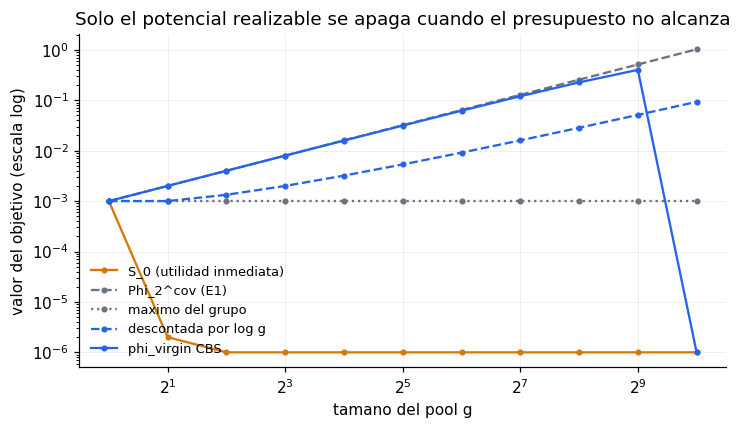

In [5]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
estilos = {'S_0 (utilidad inmediata)': (AMBAR, '-'), 'Phi_2^cov (E1)': (GRIS, '--'),
           'maximo del grupo': (GRIS, ':'), 'descontada por log g': (AZUL, '--'),
           'phi_virgin CBS': (AZUL, '-')}
for k, c in curvas.items():
    color, ls = estilos[k]
    ax.plot(gs, np.maximum(c, 1e-6), color=color, ls=ls, marker='o', ms=3, label=k)
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('tamano del pool g')
ax.set_ylabel('valor del objetivo (escala log)')
ax.set_title('Solo el potencial realizable se apaga cuando el presupuesto no alcanza')
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
fig.tight_layout()
plt.show()

**Lectura.** La utilidad inmediata se desploma porque exige que las g personas
salgan sanas a la vez, y el promedio del maximo sale plano en el caso homogeneo.
La V lineal si crece con g, pero por la razon vacia de E1: cuenta masa de prior,
no informacion, y crece sin techo aunque el presupuesto no alcance para extraer
nada.

phi_virgin CBS es la unica que mide lo que de verdad se cobra, y por eso es la
unica que se apaga: crece hasta 0.4009 en g=512 y cae a cero en 1024, porque bajo
strict hard clearing abrir ese pool pide una prueba mas de las que hay. Ese
acantilado no es un defecto del objetivo sino la restriccion de presupuesto
entrando en el score, que es justo lo que el plan pide de un potencial
realizable.

**Para discutir.** La utilidad extraible usa el presupuesto restante y el costo
del binary search, o sea que ya es medio valor de continuacion. Cuanto de eso se
puede meter en el objetivo antes de que deje de ser un paso goloso y se vuelva
programacion dinamica disfrazada?

## E3. La submodularidad adaptativa falla, y falla por el mecanismo del ejemplo

Submodular quiere decir rendimientos decrecientes: la ganancia de una accion no
crece cuando ya se sabe mas. Aqui pasa lo contrario. Con cuatro personas y
probabilidad 0.05 de estar sanas, probar a la persona 0 al principio gana
0.05 por u. Si antes se probo el trio 0-1-2 y salio que hay dos activos,
probar a la persona 0 gana 1/3 por u: la ganancia se multiplico por siete.

**La afirmacion [VERIFICADO n<=4].** El registro de claims marca C5 como
derivacion condicional y anota que el falsificador busca ademas el testigo directo
(psi, psi', t). Aqui esta ese testigo, por enumeracion exacta: hay ternas donde
Delta(t | psi') supera a Delta(t | psi) con psi contenida en psi'. Las violaciones
se separan en dos causas, la contable cuando la accion vuelve a tocar gente ya
acreditada y la genuina cuando el conteo concentra la probabilidad de estar sano
en pocos candidatos. Ambas son legitimas bajo la definicion; la separacion muestra
que el resultado no depende de la contabilidad de acreditados.

In [6]:
def ganancia(ev, worlds, cleared, pool):
    '''Ganancia marginal esperada de probar pool en el estado dado.'''
    return sum(pr * rw for pr, _, _, rw in ev.branches(worlds, cleared, pool))


def hijos(ev, worlds, cleared, pool):
    '''(R, probabilidad, mundos, cleared) de cada rama con masa positiva.'''
    total = ev.mass(worlds)
    salida = []
    for R, compat in enumerate(ev.outcome_worlds[pool]):
        child = worlds & compat
        m = ev.mass(child)
        if m > 0.0:
            salida.append((R, m / total, child, cleared | pool if R == 0 else cleared))
    return salida


n, q_sano = 4, 0.05
ev = ExactPolicyEvaluator(np.full(n, 1.0 - q_sano), np.ones(n), B=3, G=3)
raiz = (ev.all_worlds, 0)

registro, monotona_ok = [], True
for t0 in ev.pools:
    for R, _, w1, c1 in hijos(ev, *raiz, t0):
        for t in ev.pools:
            if t == t0:
                continue          # la condicion pide t fuera del dominio de psi'
            g_raiz = ganancia(ev, *raiz, t)
            g_hijo = ganancia(ev, w1, c1, t)
            monotona_ok &= (g_raiz >= -1e-12 and g_hijo >= -1e-12)
            contable = bool(t & c1)        # la accion vuelve a tocar acreditados
            viola = g_hijo > g_raiz + 1e-9
            registro.append((t0, R, t, g_raiz, g_hijo, contable, viola))

genuinas = [r for r in registro if r[6] and not r[5]]
contables = [r for r in registro if r[6] and r[5]]

assert monotona_ok, 'la monotonia adaptativa deberia cumplirse siempre'
assert genuinas, 'se esperaban violaciones que no vengan de re-probar acreditados'

peor = max(genuinas, key=lambda r: r[4] / max(r[3], 1e-15))
print(f'pares (historia observada, accion) revisados: {len(registro)}')
print(f'monotonia adaptativa: se cumple en todos los casos')
print(f'violaciones por contabilidad (la accion re-toca acreditados): {len(contables)}')
print(f'violaciones genuinas: {len(genuinas)}')
print(f'\npeor violacion genuina: observar conteo R={peor[1]} en un pool de '
      f'{bin(peor[0]).count("1")} personas sube la ganancia de probar un pool de '
      f'{bin(peor[2]).count("1")} de {peor[3]:.4f} a {peor[4]:.4f}, '
      f'factor {peor[4] / peor[3]:.1f}')

pares (historia observada, accion) revisados: 546
monotonia adaptativa: se cumple en todos los casos
violaciones por contabilidad (la accion re-toca acreditados): 96
violaciones genuinas: 120

peor violacion genuina: observar conteo R=1 en un pool de 3 personas sube la ganancia de probar un pool de 2 de 0.0050 a 0.6667, factor 133.3


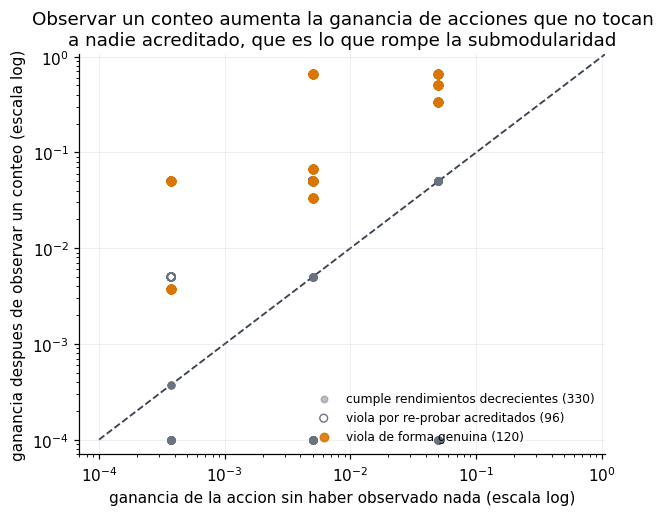

In [7]:
PISO = 1e-4          # las ganancias nulas se dibujan en el piso de la escala log


def xy(filas):
    return (np.maximum([r[3] for r in filas], PISO),
            np.maximum([r[4] for r in filas], PISO))

cumplen = [r for r in registro if not r[6]]
xc, yc = xy(cumplen); xg, yg = xy(genuinas); xt, yt = xy(contables)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
lim = max(yg.max(), yt.max(), xc.max()) * 1.6
ax.plot([PISO, lim], [PISO, lim], color=TINTA, lw=1.2, ls='--', zorder=1)
ax.scatter(xc, yc, s=18, color=GRIS, alpha=0.45, zorder=2,
           label=f'cumple rendimientos decrecientes ({len(cumplen)})')
ax.scatter(xt, yt, s=26, facecolors='none', edgecolors=GRIS, lw=0.9, zorder=3,
           label=f'viola por re-probar acreditados ({len(contables)})')
ax.scatter(xg, yg, s=30, color=AMBAR, alpha=0.9, zorder=4,
           label=f'viola de forma genuina ({len(genuinas)})')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(PISO * 0.7, lim); ax.set_ylim(PISO * 0.7, lim)
ax.set_xlabel('ganancia de la accion sin haber observado nada (escala log)')
ax.set_ylabel('ganancia despues de observar un conteo (escala log)')
ax.set_title('Observar un conteo aumenta la ganancia de acciones que no tocan\n'
             'a nadie acreditado, que es lo que rompe la submodularidad')
ax.legend(frameon=False, fontsize=8, loc='lower right')
fig.tight_layout()
plt.show()

**Lectura.** La monotonia adaptativa se cumple siempre, como se esperaba: probar
nunca hace dano. La submodularidad adaptativa no, y las violaciones que quedan
despues de descontar las contables siguen siendo muchas. La escala es
logaritmica y las ganancias nulas se dibujan en el piso.

No es un accidente numerico: es el mismo mecanismo que hace funcionar al ejemplo
canonico. El conteo concentra la probabilidad de estar sano en pocos candidatos,
asi que la prueba que viene despues vale mas de lo que valia antes. La prueba
grande no paga sola, paga porque habilita el binary search, y esa
complementariedad es exactamente lo contrario de los rendimientos decrecientes.

**Para discutir.** Con el testigo directo, C5 puede subir de derivacion
condicional a demostrado en el mapeo pools-como-items, que es A-M17. Pero el plan
avisa que la pregunta viva no es esa: es si existe una funcion adaptativa asociada
al surrogate cuyas ganancias marginales coincidan con el scorer o lo acoten. El
testigo cierra la puerta uno y deja abierta la tres. Conviene correr el mismo
falsificador sobre nodos de jerarquia fija, que es el mapeo que el plan declara
prioritario?

## E4. Un segundo ejemplo de separacion que ya estaba en los datos

Cuando la prevalencia es alta y todos los perfiles son iguales, el greedy hace
pruebas individuales y nunca vuelve a entrar a un pool ya observado. La sospecha
de la sesion era que en ese regimen todo coincide. La mitad es cierta.

**La afirmacion [VERIFICADO n=5].** Con perfiles homogeneos y probabilidad de actividad al menos
0.5, el greedy dinamico aumentado iguala exactamente al greedy estatico, pero el
optimo dinamico aumentado queda estrictamente arriba y un paso de anticipacion
recupera casi todo.

In [8]:
n, Bud, G = 5, 3, 2
ps = np.round(np.arange(0.50, 0.91, 0.05), 2)
filas = []
for p_base in ps:
    p = np.full(n, float(p_base)); u = np.ones(n)
    v_opt = dynamic_augmented_value(p, u, Bud, G)
    v_gre = greedy_laminar_value(p, u, Bud, G)
    v_rol = rollout_laminar_value(p, u, Bud, G)
    v_est = static_greedy_value(p, u, Bud, G)
    filas.append((p_base, v_opt, v_gre, v_rol, v_est))

for p_base, v_opt, v_gre, v_rol, v_est in filas:
    assert abs(v_gre - v_est) < 1e-9, (p_base, v_gre, v_est)
    assert v_gre <= v_opt + 1e-9 and v_rol <= v_opt + 1e-9

brechas = [(v_opt - v_gre) / v_opt for _, v_opt, v_gre, _, _ in filas]
assert max(brechas) > 1e-6, 'se esperaba separacion estricta en alguna p'

# La forma cerrada de las tres politicas, y el umbral donde el rollout es optimo.
umbral = 2.0 - math.sqrt(2.0)                       # p >= 2 - raiz(2) ~ 0.5858
for p_base, v_opt, v_gre, v_rol, _ in filas:
    qq = 1.0 - p_base
    assert abs(v_gre - 3.0 * qq) < 1e-9             # greedy: tres individuales
    assert abs(v_rol - qq * (3 * qq ** 2 - 3 * qq + 4)) < 1e-9   # par y luego individuales
    if p_base >= umbral:
        assert abs(v_opt - v_rol) < 1e-9            # ahi esa politica ya es la optima
    else:
        assert v_opt > v_rol + 1e-9

print(f'n={n}, B={Bud}, G={G}, perfiles homogeneos')
print(f'greedy = 3q;  rollout = q(3q^2 - 3q + 4);  ambos verificados en la rejilla')
print(f'el rollout alcanza el optimo exactamente desde p = 2 - raiz(2) = {umbral:.4f}\n')
print(f"{'p':>6} {'optimo':>9} {'greedy':>9} {'rollout':>9} {'g.estatico':>11} "
      f"{'greedy/opt':>11} {'rollout/opt':>12}")
for p_base, v_opt, v_gre, v_rol, v_est in filas:
    print(f'{p_base:6.2f} {v_opt:9.4f} {v_gre:9.4f} {v_rol:9.4f} {v_est:11.4f} '
          f'{v_gre / v_opt:11.4f} {v_rol / v_opt:12.4f}')

n=5, B=3, G=2, perfiles homogeneos
greedy = 3q;  rollout = q(3q^2 - 3q + 4);  ambos verificados en la rejilla
el rollout alcanza el optimo exactamente desde p = 2 - raiz(2) = 0.5858

     p    optimo    greedy   rollout  g.estatico  greedy/opt  rollout/opt
  0.50    1.6875    1.5000    1.6250      1.5000      0.8889       0.9630
  0.55    1.4912    1.3500    1.4659      1.3500      0.9053       0.9830
  0.60    1.3120    1.2000    1.3120      1.2000      0.9146       1.0000
  0.65    1.1611    1.0500    1.1611      1.0500      0.9043       1.0000
  0.70    1.0110    0.9000    1.0110      0.9000      0.8902       1.0000
  0.75    0.8594    0.7500    0.8594      0.7500      0.8727       1.0000
  0.80    0.7040    0.6000    0.7040      0.6000      0.8523       1.0000
  0.85    0.5426    0.4500    0.5426      0.4500      0.8293       1.0000
  0.90    0.3730    0.3000    0.3730      0.3000      0.8043       1.0000


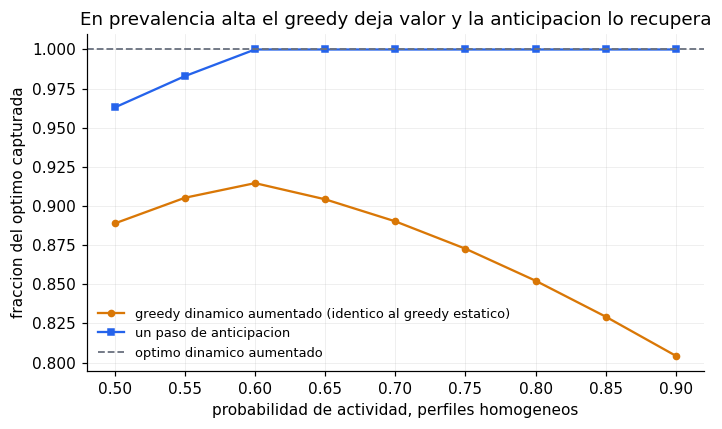

In [9]:
arr = np.array(filas)
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(arr[:, 0], arr[:, 2] / arr[:, 1], color=AMBAR, marker='o', ms=4,
        label='greedy dinamico aumentado (identico al greedy estatico)')
ax.plot(arr[:, 0], arr[:, 3] / arr[:, 1], color=AZUL, marker='s', ms=4,
        label='un paso de anticipacion')
ax.axhline(1.0, color=GRIS, ls='--', lw=1.2, label='optimo dinamico aumentado')
ax.set_xlabel('probabilidad de actividad, perfiles homogeneos')
ax.set_ylabel('fraccion del optimo capturada')
ax.set_title('En prevalencia alta el greedy deja valor y la anticipacion lo recupera')
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
fig.tight_layout()
plt.show()

**Lectura.** El greedy coincide con el greedy estatico digito por digito en todo
el rango, o sea que en este regimen el dinamico aumentado degenera en un diseno
estatico. Y sin embargo el optimo esta estrictamente arriba, con una brecha que
crece de 11% a 20% conforme sube la prevalencia.

Lo llamativo es lo barato que sale cerrarla, y no es coincidencia numerica sino
un cambio de politica con umbral exacto. El greedy vale 3q porque hace tres
individuales. El rollout prueba primero un par y despues individuales segun el
conteo, lo que vale q(3q^2 - 3q + 4). Esa politica pasa a ser la optima cuando
q <= raiz(2) - 1, o sea desde p = 2 - raiz(2), que es 0.5858. Por eso las dos
curvas se pegan a partir de ahi y no antes.

Es un regimen entero, no un ejemplo suelto, donde la planificacion es lo unico
que paga y donde ademas paga con un solo paso de anticipacion. La separacion es
estricta para 0.5 <= p < 1; en p = 1 todo vale cero y la comparacion se vacia.

**Para discutir.** El ejemplo canonico y este regimen separan por el mismo
mecanismo o por dos distintos? Si es el mismo, hay una familia con un parametro
que los contiene a los dos y eso es un enunciado mas fuerte que dos ejemplos.

## E5. El umbral de 0.5, con utilidades heterogeneas

Con pruebas binarias y perfiles identicos, agrupar deja de convenir cuando la
probabilidad de estar sano baja de 0.5: el par gana 2q^2 contra q de la
individual. Lo que no esta claro es si el umbral sobrevive cuando las utilidades
y las probabilidades son distintas entre personas.

**La afirmacion [DEMOSTRADO].** En instancias heterogeneas donde todos tienen probabilidad de
estar sanos menor a 0.5, el mejor diseno estatico es siempre tomar las B
personas de mayor u_i*q_i por separado.

In [10]:
def optimo_individual(p, u, B):
    '''Mejor diseno estatico restringido a pruebas individuales.'''
    valores = np.sort(u * (1.0 - p))[::-1]
    return float(valores[:B].sum())


rng = np.random.default_rng(2307)
casos, fallos = 0, []
for _ in range(60):
    n = int(rng.integers(4, 6))
    Bud, G = int(rng.integers(2, 4)), int(rng.integers(2, 4))
    p = rng.uniform(0.50 + 1e-6, 0.99, size=n)     # todos con q_i < 0.5
    u = rng.uniform(0.5, 4.0, size=n)
    ev = ExactPolicyEvaluator(p, u, Bud, G)
    exacto, individual = ev.static_value(), optimo_individual(p, u, Bud)
    casos += 1
    if exacto > individual + 1e-9:
        fallos.append((p.copy(), u.copy(), Bud, G, exacto, individual))

print(f'instancias heterogeneas con todos los q_i < 0.5: {casos}')
print(f'contraejemplos al umbral: {len(fallos)}')
assert not fallos, fallos[:1]

instancias heterogeneas con todos los q_i < 0.5: 60
contraejemplos al umbral: 0


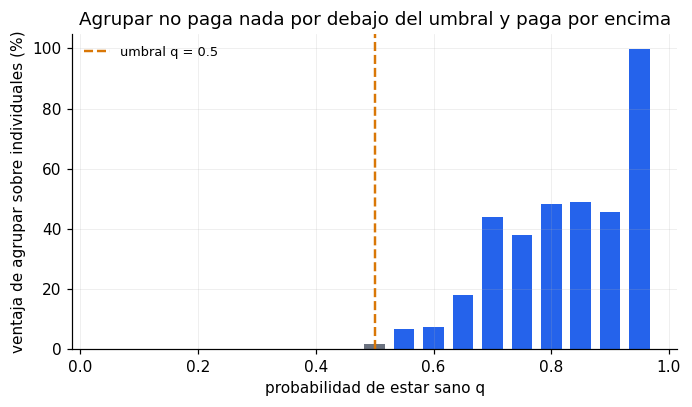

In [11]:
# El control: bajando la prevalencia el umbral deja de valer y agrupar si paga.
rng = np.random.default_rng(11)
ventajas = []
rejilla = np.round(np.arange(0.05, 0.96, 0.05), 2)
for p_base in rejilla:
    mejor = 0.0
    for _ in range(6):
        n, Bud, G = 5, 2, 3
        p = np.clip(rng.normal(p_base, 0.05, size=n), 0.01, 0.99)
        u = rng.uniform(0.5, 4.0, size=n)
        ev = ExactPolicyEvaluator(p, u, Bud, G)
        mejor = max(mejor, ev.static_value() / optimo_individual(p, u, Bud) - 1.0)
    ventajas.append(mejor)

ventajas = np.array(ventajas)
q_rejilla = 1.0 - rejilla
assert ventajas[q_rejilla < 0.5].max() < 1e-9
assert ventajas[q_rejilla > 0.5].max() > 1e-6

fig, ax = plt.subplots(figsize=(6.4, 3.8))
color = [AZUL if qq > 0.5 else GRIS for qq in q_rejilla]
ax.bar(q_rejilla, 100 * ventajas, width=0.035, color=color)
ax.axvline(0.5, color=AMBAR, ls='--', lw=1.6, label='umbral q = 0.5')
ax.set_xlabel('probabilidad de estar sano q')
ax.set_ylabel('ventaja de agrupar sobre individuales (%)')
ax.set_title('Agrupar no paga nada por debajo del umbral y paga por encima')
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
plt.show()

**Lectura.** En 60 instancias heterogeneas con todos los perfiles por debajo del
umbral, el mejor diseno estatico coincide exactamente con tomar las mejores B
individuales; no aparece un solo contraejemplo. Del otro lado del umbral la
ventaja de agrupar es estrictamente positiva.

Y hay demostracion, no solo evidencia. Llamando a_i = u_i q_i y x_i a la
probabilidad de que i quede certificado dado que esta sano, el bienestar es la
suma de a_i x_i. Por cota de union, x_i no pasa de la suma, sobre los pools del
diseno que contienen a i, del producto de los q_j de los demas miembros. Sumando
sobre i, cada pool T aporta a lo mas |T| / 2^(|T|-1) cuando todos los q_j estan
por debajo de 1/2, y esa cantidad nunca pasa de 1. Entonces la suma de los x_i no
pasa de B, asi que el bienestar no pasa de la suma de los B mayores a_i, que es
justo lo que dan las pruebas individuales.

**Para discutir.** La demostracion usa independencia, utilidades no negativas,
certificacion solo por R = 0 y diseno estatico, y se rompe apenas se sale de ahi:
con presupuesto 1, dos personas identicas y q por encima de 1/2, el par vale
2uq^2 y le gana a la individual. Cual de esos cuatro supuestos es el que
conviene relajar primero para el paper?

## B1. La linea base que falta, y que aqui se calcula

La separacion del paper compara el mejor diseno **estatico binario** contra el
**dinamico aumentado**. Entre esos dos hay dos cambios a la vez, no uno: se gana
adaptatividad y se gana el conteo. Sin la celda intermedia, el dinamico binario,
no se puede decir cuanto aporta cada cosa.

**La afirmacion [VERIFICADO n=5].** Las tres filas de la tabla de §18 —estatica
binaria, dinamica binaria, dinamica conteo— calculadas sobre la familia de
separacion. La celda intermedia no requiere maquinaria nueva:
`solve_classical_dynamic` ya resuelve el optimo dinamico binario exacto. El
desenlace, de los cuatro que §18 declara posibles sin apostar, es "casi todo
conteo" y en su version extrema: el dinamico binario iguala exactamente al
estatico binario, asi que la adaptatividad por si sola no aporta nada.

In [12]:
n, Bud, G = 5, 3, 2
ps = np.round(np.arange(0.50, 0.91, 0.05), 2)

filas_b1 = []
for p_base in ps:
    p = np.full(n, float(p_base)); u = np.ones(n)
    ev = ExactPolicyEvaluator(p, u, Bud, G)
    v_est_bin = ev.static_value()                          # estatico binario
    v_din_bin = float(solve_classical_dynamic(p, u, Bud, G)[0])   # dinamico binario
    v_din_aum = dynamic_augmented_value(p, u, Bud, G)      # dinamico aumentado
    filas_b1.append((p_base, v_est_bin, v_din_bin, v_din_aum))

for p_base, e, d, a in filas_b1:
    assert e <= d + 1e-9, (p_base, e, d)      # lo estatico es un caso de lo dinamico
    assert d <= a + 1e-9, (p_base, d, a)      # el binario es un garbling del conteo
    assert abs(d - e) < 1e-9, (p_base, e, d)  # y aqui ademas coinciden
    assert a > d + 1e-9, (p_base, d, a)       # mientras el conteo separa estrictamente

print(f'n={n}, B={Bud}, G={G}, perfiles homogeneos')
print(f"{'p':>6} {'est.binario':>12} {'din.binario':>12} {'din.aumentado':>14} "
      f"{'adaptatividad':>14} {'conteo':>9}")
for p_base, e, d, a in filas_b1:
    print(f'{p_base:6.2f} {e:12.4f} {d:12.4f} {a:14.4f} '
          f'{100 * (d - e) / e:13.1f}% {100 * (a - d) / d:8.1f}%')

n=5, B=3, G=2, perfiles homogeneos
     p  est.binario  din.binario  din.aumentado  adaptatividad    conteo
  0.50       1.5000       1.5000         1.6875           0.0%     12.5%
  0.55       1.3500       1.3500         1.4912          -0.0%     10.5%
  0.60       1.2000       1.2000         1.3120           0.0%      9.3%
  0.65       1.0500       1.0500         1.1611          -0.0%     10.6%
  0.70       0.9000       0.9000         1.0110           0.0%     12.3%
  0.75       0.7500       0.7500         0.8594           0.0%     14.6%
  0.80       0.6000       0.6000         0.7040           0.0%     17.3%
  0.85       0.4500       0.4500         0.5426          -0.0%     20.6%
  0.90       0.3000       0.3000         0.3730           0.0%     24.3%


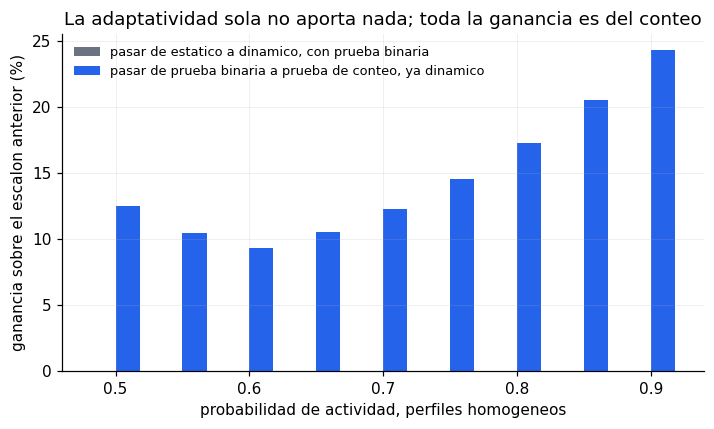

In [13]:
arr = np.array(filas_b1)
g_adapt = 100 * (arr[:, 2] - arr[:, 1]) / arr[:, 1]
g_conteo = 100 * (arr[:, 3] - arr[:, 2]) / arr[:, 2]

fig, ax = plt.subplots(figsize=(6.6, 4.0))
w = 0.018
ax.bar(arr[:, 0] - w / 2, g_adapt, width=w, color=GRIS,
       label='pasar de estatico a dinamico, con prueba binaria')
ax.bar(arr[:, 0] + w / 2, g_conteo, width=w, color=AZUL,
       label='pasar de prueba binaria a prueba de conteo, ya dinamico')
ax.set_xlabel('probabilidad de actividad, perfiles homogeneos')
ax.set_ylabel('ganancia sobre el escalon anterior (%)')
ax.set_title('La adaptatividad sola no aporta nada; toda la ganancia es del conteo')
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
plt.show()

**Lectura.** El escalon de la adaptatividad es cero en toda la rejilla: con prueba
binaria y perfiles homogeneos, poder ver la historia antes de decidir no compra
nada, porque el unico resultado que acredita es el pool limpio y ahi ya no queda
nada que replanificar. El segundo escalon va de 9.3% a 24.3% y crece con la
prevalencia.

Eso es mas fuerte que lo que pedia la auditoria. No solo se puede separar la
contribucion de cada feature: resulta que una de las dos es exactamente cero, asi
que la separacion completa es atribuible al conteo y no queda ninguna ambiguedad
sobre a que se le acredita la ganancia. En terminos del registro de claims, esto es evidencia para C4 en la rejilla
n=5, B=3, G=2 con perfiles homogeneos, no su cierre: la familia de separacion del
paper es asintotica y la celda queda pendiente hasta cubrirla.

**Para discutir.** Este desglose es en n=5. La familia de separacion del paper es
asintotica, con poblacion infinita. Conviene reportar el desglose en la instancia
chica, o derivar el termino dinamico binario en la familia asintotica?

## B2. El ancla del acid test, en la convencion normativa

El plan maestro fija strict hard clearing como modelo normativo (gate G0) y deja
la variante deductiva como un modelo distinto y nombrado, que no se mezcla. Con
esa convencion hace falta una prueba extra para acreditar, asi que el numero de
pools raiz es k = max{0, B - techo(log2 G) - 1}.

El ancla ejecutable declarada es (q, G, k, B) = (0.05, 16, 2, 7).

**La afirmacion [DEMOSTRADO, forma cerrada del plan].** En el ancla normativa la cota dinamico-conteo vale
0.806u contra 0.35u del baseline singleton, que es el valor de S_0 y coincide con
el optimo estatico ahi. La separacion se sostiene en toda la vecindad declarada de
G, y se cierra cuando el presupuesto crece porque la cota satura en u.

In [14]:
q_a, u_a = 0.05, 1.0                    # ancla del acid test: q = P(sano)


def k_raiz(B, G):
    '''Pools raiz bajo strict hard clearing: el test acreditador ya descontado.'''
    return max(0, B - math.ceil(math.log2(G)) - 1)


def S0_singleton(B):
    '''Baseline singleton: B pruebas individuales.'''
    return B * u_a * q_a


def cota_conteo(B, G):
    '''Cota inferior realizable: k pools de tamano G mas busqueda binaria.'''
    k = k_raiz(B, G)
    return 0.0 if k == 0 else u_a * (1.0 - (1.0 - q_a) ** (k * G))


# El ancla declarada, contra los dos numeros que cita el plan maestro.
assert k_raiz(7, 16) == 2
assert abs(cota_conteo(7, 16) - 0.806) < 5e-4
assert abs(S0_singleton(7) - 0.35) < 1e-12

Gs = (2, 4, 8, 16)                      # vecindad declarada
Bs = np.arange(5, 13)
curvas_b2 = {G: np.array([cota_conteo(int(B), G) for B in Bs]) for G in Gs}
base_b2 = np.array([S0_singleton(int(B)) for B in Bs])

print(f'ancla del acid test: q = {q_a}, G = 16, k = {k_raiz(7, 16)}, B = 7, u = 1')
print(f'  cota dinamico-conteo {cota_conteo(7, 16):.4f}u  contra  '
      f'baseline singleton S_0 {S0_singleton(7):.4f}u\n')
cabecera = f"{'B':>3} {'S_0':>8}" + ''.join(f'{("G=" + str(G)):>10}' for G in Gs)
print(cabecera)
for i, B in enumerate(Bs):
    print(f'{B:3d} {base_b2[i]:8.4f}' + ''.join(f'{curvas_b2[G][i]:10.4f}' for G in Gs))

ventana = [int(B) for i, B in enumerate(Bs) if curvas_b2[16][i] > base_b2[i]]
print(f'\ncon G=16 la cota supera al baseline para B en {ventana}')

ancla del acid test: q = 0.05, G = 16, k = 2, B = 7, u = 1
  cota dinamico-conteo 0.8063u  contra  baseline singleton S_0 0.3500u

  B      S_0       G=2       G=4       G=8      G=16
  5   0.2500    0.2649    0.3366    0.3366    0.0000
  6   0.3000    0.3366    0.4596    0.5599    0.5599
  7   0.3500    0.4013    0.5599    0.7080    0.8063
  8   0.4000    0.4596    0.6415    0.8063    0.9147
  9   0.4500    0.5123    0.7080    0.8715    0.9625
 10   0.5000    0.5599    0.7622    0.9147    0.9835
 11   0.5500    0.6028    0.8063    0.9434    0.9927
 12   0.6000    0.6415    0.8422    0.9625    0.9968

con G=16 la cota supera al baseline para B en [6, 7, 8, 9, 10, 11, 12]


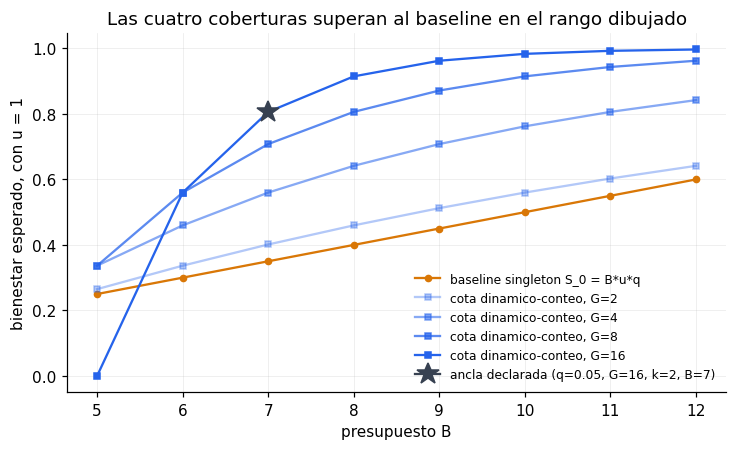

In [15]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(Bs, base_b2, color=AMBAR, marker='o', ms=4,
        label='baseline singleton S_0 = B*u*q')
tonos = {2: 0.35, 4: 0.55, 8: 0.75, 16: 1.0}
for G in Gs:
    ax.plot(Bs, curvas_b2[G], color=AZUL, alpha=tonos[G], marker='s', ms=4,
            label=f'cota dinamico-conteo, G={G}')
ax.plot([7], [cota_conteo(7, 16)], marker='*', ms=15, color=TINTA, zorder=5,
        label='ancla declarada (q=0.05, G=16, k=2, B=7)')
ax.set_xlabel('presupuesto B')
ax.set_ylabel('bienestar esperado, con u = 1')
ax.set_title('Las cuatro coberturas superan al baseline en el rango dibujado')
ax.legend(frameon=False, fontsize=8, loc='lower right')
fig.tight_layout()
plt.show()

**Lectura.** En el ancla declarada la cota vale 0.8063u contra 0.3500u del
baseline singleton, que reproduce el par de numeros del registro de claims. La
separacion se sostiene para los cuatro G de la vecindad en todo el rango de
presupuesto dibujado; la unica celda vacia es G=16 con B=5, donde k queda en cero
y el presupuesto no alcanza ni para un pool raiz mas su busqueda.

Hay un limite que conviene declarar aunque no se vea en la figura. La cota satura
en u porque solo cuenta encontrar a una persona sana, mientras el baseline crece
lineal en B, asi que las dos se cruzan cuando B*q se acerca a 1, o sea alrededor
de B = 20 con q = 0.05. La separacion vive en una ventana de presupuestos amplia
pero acotada, y el enunciado deberia decirlo.

Nota de convencion: todo esto es strict hard clearing, el modelo normativo. La
variante deductiva es un modelo distinto y nombrado, y sus numeros no se mezclan
con estos.

**Para discutir.** La cota es floja por construccion, porque solo cuenta encontrar
a una persona sana e ignora que con presupuesto grande se corren varias busquedas
binarias. Conviene refinarla para que no sature, o enunciar la separacion dentro
de la ventana y declarar el limite?

## B3. Lo que la suite verde no cubre

La suite pasa con unos 215 tests, y eso da una sensacion de cobertura que en tres
puntos no corresponde. Los tres son verificables desde aqui, asi que conviene
verlos en vez de creerlos.

**La afirmacion [VERIFICADO n=40].** El archivo que valida el muestreador de Gibbs no lo colecta
pytest, dos de los CSV mas citados no tienen script generador, y en la corrida de
n=40 el rollout devuelve exactamente lo mismo que el greedy.

In [16]:
def funciones_test(ruta):
    arbol = ast.parse(ruta.read_text(encoding='utf-8'))
    return [nodo.name for nodo in arbol.body
            if isinstance(nodo, ast.FunctionDef) and nodo.name.startswith('test_')]

gibbs = RAIZ / 'tests_gibbs_validity.py'
otros = sorted(p for p in RAIZ.glob('tests_*.py') if p != gibbs)
assert funciones_test(gibbs) == [], 'ya lo colecta pytest, actualizar esta seccion'
print(f'{gibbs.name}: {len(funciones_test(gibbs))} funciones test_ (pytest no lo colecta)')
print(f'los otros {len(otros)} archivos tests_*.py suman '
      f'{sum(len(funciones_test(p)) for p in otros)} funciones test_\n')

fuentes = list(RAIZ.glob('*.py')) + list((RAIZ / 'notebooks').glob('*.py'))
for nombre in ('arbol_vs_miopia', 'greedy_vs_static_greedy'):
    generadores = [p.name for p in fuentes if nombre in p.read_text(encoding='utf-8')]
    escritores = [g for g in generadores if not g.startswith('build_experimentos')]
    assert not escritores, (nombre, escritores)
    print(f'{nombre}.csv: sin script generador versionado')

resumen = {f['method']: f for f in
           csv.DictReader(open(RAIZ / 'data' / 'laminar_week' / 'pipeline_n40_summary.csv'))}
gre, rol = resumen['laminar_greedy'], resumen['laminar_rollout']
campos = ('mean_utility', 'standard_error', 'median_utility', 'zero_rate')
assert all(gre[c] == rol[c] for c in campos), 'el rollout ya se movio a n=40'
print(f"\nn=40: greedy y rollout coinciden en {', '.join(campos)}")
print(f"      ambos {float(gre['mean_utility']):.3f} contra "
      f"{float(resumen['flat_independence']['mean_utility']):.3f} del control plano")

tests_gibbs_validity.py: 0 funciones test_ (pytest no lo colecta)


los otros 13 archivos tests_*.py suman 136 funciones test_

arbol_vs_miopia.csv: sin script generador versionado
greedy_vs_static_greedy.csv: sin script generador versionado

n=40: greedy y rollout coinciden en mean_utility, standard_error, median_utility, zero_rate
      ambos 10.069 contra 11.267 del control plano


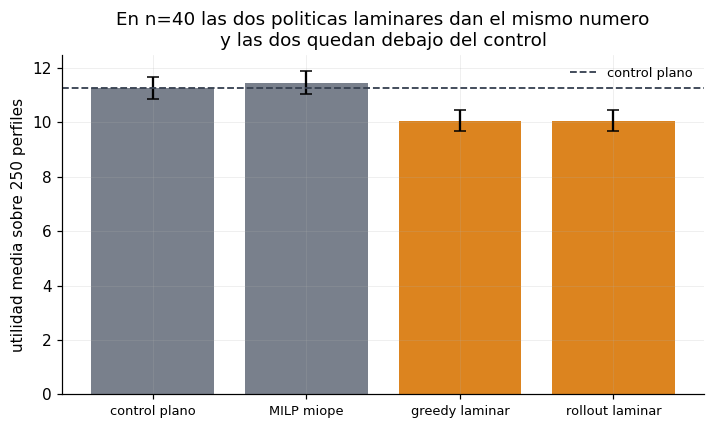

In [17]:
orden = ['flat_independence', 'myopic_milp', 'laminar_greedy', 'laminar_rollout']
medias = [float(resumen[m]['mean_utility']) for m in orden]
errores = [float(resumen[m]['standard_error']) for m in orden]
colores = [GRIS, GRIS, AMBAR, AMBAR]

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.bar(range(4), medias, yerr=errores, capsize=4, color=colores, alpha=0.9)
ax.axhline(medias[0], color=TINTA, ls='--', lw=1.2, label='control plano')
ax.set_xticks(range(4))
ax.set_xticklabels(['control plano', 'MILP miope', 'greedy laminar', 'rollout laminar'],
                   fontsize=8.5)
ax.set_ylabel('utilidad media sobre 250 perfiles')
ax.set_title('En n=40 las dos politicas laminares dan el mismo numero\n'
             'y las dos quedan debajo del control')
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
plt.show()

**Lectura.** Que el rollout coincida con el greedy hasta el ultimo digito en media,
error estandar, mediana y tasa de cero no es un empate: es que no se esta
ejecutando. Y ambos quedan por debajo del control mas simple, asi que ningun
numero de n=40 es reportable todavia.

Lo del Gibbs es mas delicado porque no se ve. El sesgo del muestreador swap-only
estaba demostrado y se corrigio con Metropolis-Hastings sobre caminos alternantes,
pero la irreducibilidad de la cadena corregida no esta demostrada en todas las
fibras, y el archivo que la valida no entra en la suite. Se paso de un sesgo
demostrado a una correccion no demostrada y no vigilada.

**Para discutir.** La salida barata para el paper es cercar toda afirmacion a
inferencia exacta y laminar, y bajar el Gibbs a apendice con la limitacion
declarada. La cara es demostrar la irreducibilidad. Cual conviene, sabiendo que
las afirmaciones a escala dependen del muestreador?

## R1. El optimo si anida donde el greedy no

E4 dejo dos cosas juntas y sin conectar: el greedy iguala al estatico y el optimo
queda arriba. Falta el mecanismo. La sospecha natural es que el optimo si vuelve a
entrar a un pool ya observado, o sea que si usa la jerarquia, y que el greedy
pierde justamente por no usarla. Es la tarea B10' del plan del 27 de julio, que
quedo sin correr.

**La afirmacion [VERIFICADO n=5].** Caminando el arbol de decisiones de las dos politicas sobre la
misma familia, el greedy nunca anida y el optimo si lo hace en una fraccion no
trivial de sus decisiones, ponderadas por probabilidad de rama.

In [18]:
def desempate(valor, pool, tol=1e-12):
    '''Regla congelada del plan: mayor score, luego menor tamano, luego menor mascara.

    Se redondea el score a la tolerancia para que los empates numericos caigan
    de verdad en el criterio de tamano y no en ruido de punto flotante.
    '''
    return (round(valor / tol), -pool.bit_count(), -pool)


def politica_optima(ev):
    '''Funcion de valor optima y su accion argmax en cada estado.'''

    @lru_cache(maxsize=None)
    def V(step, worlds, cleared):
        if step == ev.B:
            return 0.0
        mejor = 0.0
        for t in ev.pools:
            v = sum(pr * (rw + V(step + 1, ch, nc))
                    for pr, ch, nc, rw in ev.branches(worlds, cleared, t))
            mejor = max(mejor, v)
        return mejor

    def accion(step, worlds, cleared):
        mejor, mejor_t = (0.0, 0, 0), None
        for t in ev.pools:
            v = sum(pr * (rw + V(step + 1, ch, nc))
                    for pr, ch, nc, rw in ev.branches(worlds, cleared, t))
            if desempate(v, t) > mejor:
                mejor, mejor_t = desempate(v, t), t
        return mejor_t

    return V, accion


def accion_greedy(ev, step, worlds, cleared):
    '''Argmax de S_0, con la misma regla de desempate.'''
    mejor, mejor_t = (0.0, 0, 0), None
    for t in ev.pools:
        s = ganancia(ev, worlds, cleared, t)
        if desempate(s, t) > mejor:
            mejor, mejor_t = desempate(s, t), t
    return mejor_t


def anidamiento(ev, selector):
    '''Fraccion de decisiones virgenes / anidadas / mixtas, ponderada por rama.'''
    cats = {'virgen': 0.0, 'anidada': 0.0, 'mixta': 0.0}
    total = 0.0

    def walk(step, worlds, cleared, probados, prob):
        nonlocal total
        if step == ev.B or prob <= 1e-15:
            return
        t = selector(step, worlds, cleared)
        if t is None:
            return
        total += prob
        union = 0
        for tp in probados:
            union |= tp
        if t & union == 0:
            cats['virgen'] += prob
        elif any((t & tp) == t for tp in probados):
            cats['anidada'] += prob
        else:
            cats['mixta'] += prob
        for pr, ch, nc, _ in ev.branches(worlds, cleared, t):
            walk(step + 1, ch, nc, probados + (t,), prob * pr)

    walk(0, ev.all_worlds, 0, (), 1.0)
    return {k: v / total for k, v in cats.items()}, total


n, Bud, G = 5, 3, 2
ps_r1 = np.round(np.arange(0.30, 0.91, 0.10), 2)
filas_r1 = []
for p_base in ps_r1:
    p = np.full(n, float(p_base)); u = np.ones(n)
    ev = ExactPolicyEvaluator(p, u, Bud, G)
    V, accion_opt = politica_optima(ev)
    assert abs(V(0, ev.all_worlds, 0) - ev.optimal_value()) < 1e-9
    c_opt, _ = anidamiento(ev, accion_opt)
    c_gre, _ = anidamiento(ev, lambda s, w, c: accion_greedy(ev, s, w, c))
    filas_r1.append((p_base, c_gre['anidada'], c_opt['anidada'], c_opt['mixta']))

altas = [f for f in filas_r1 if f[0] >= 0.5]
assert all(abs(f[1]) < 1e-12 for f in altas), 'el greedy no deberia anidar en p>=0.5'
assert max(f[2] for f in altas) > 1e-6, 'se esperaba que el optimo si anide'

print(f'n={n}, B={Bud}, G={G}, perfiles homogeneos')
print(f"{'p':>6} {'anida greedy':>14} {'anida optimo':>14} {'mixta optimo':>14}")
for p_base, a_g, a_o, m_o in filas_r1:
    print(f'{p_base:6.2f} {a_g:14.3f} {a_o:14.3f} {m_o:14.3f}')

n=5, B=3, G=2, perfiles homogeneos
     p   anida greedy   anida optimo   mixta optimo
  0.30          0.000          0.000          0.231
  0.40          0.000          0.000          0.272
  0.50          0.000          0.042          0.250
  0.60          0.000          0.240          0.000
  0.70          0.000          0.210          0.000
  0.80          0.000          0.160          0.000
  0.90          0.000          0.090          0.000


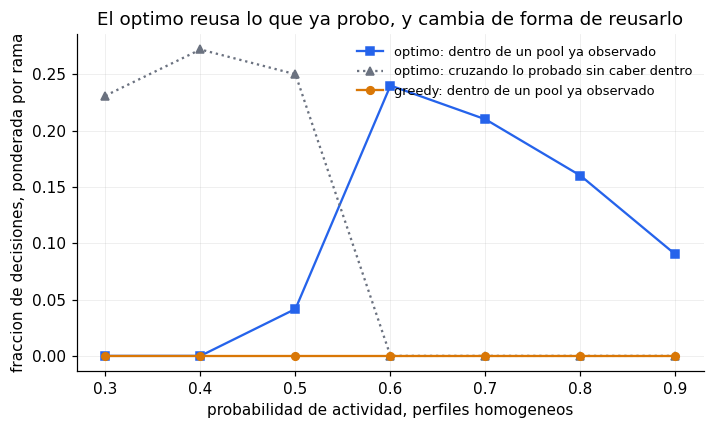

In [19]:
arr = np.array(filas_r1)
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(arr[:, 0], arr[:, 2], color=AZUL, marker='s', ms=5,
        label='optimo: dentro de un pool ya observado')
ax.plot(arr[:, 0], arr[:, 3], color=GRIS, marker='^', ms=5, ls=':',
        label='optimo: cruzando lo probado sin caber dentro')
ax.plot(arr[:, 0], arr[:, 1], color=AMBAR, marker='o', ms=5,
        label='greedy: dentro de un pool ya observado')
ax.set_xlabel('probabilidad de actividad, perfiles homogeneos')
ax.set_ylabel('fraccion de decisiones, ponderada por rama')
ax.set_title('El optimo reusa lo que ya probo, y cambia de forma de reusarlo')
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
plt.show()

**Lectura.** El greedy gasta el 100% de sus decisiones en territorio virgen en
todo el rango, y el optimo no. Ese es el mecanismo que faltaba para E4: la brecha
no viene de elegir mejor el primer pool sino de volver sobre lo ya probado.

Y hay un cambio de regimen limpio en el camino. Por debajo de 0.5 el optimo
tampoco anida, pero gasta entre 23% y 27% de sus decisiones en pools que cruzan lo
probado sin caber dentro. A partir de 0.6 las mixtas desaparecen del todo y las
anidadas suben hasta 24%. O sea que el optimo reusa informacion en los dos
regimenes, pero cambia de forma de hacerlo justo donde la separacion aparece, y
solo la segunda forma es laminar.

**Para discutir.** El optimo anida despues de ver conteos intermedios, que son
los que el modelo binario no puede distinguir. Se puede convertir eso en un
enunciado: que la ventaja del conteo sobre el binario es exactamente el valor de
poder anidar?

## R2. Creencias exactas contra acciones libres

Hay dos cosas distintas que el tensor y la restriccion laminar compran, y siempre
se han medido juntas. Una es calcular bien: usar el posterior exacto en vez del
producto de marginales. La otra es poder elegir cualquier pool en vez de quedarse
dentro de una biblioteca laminar. Es la tarea B11' del plan, descrita ahi como la
comparacion que nadie ha corrido.

**La afirmacion [VERIFICADO n=5, 12 instancias].** Separando las dos perillas en un 2x2 sobre instancias
heterogeneas, calcular bien y elegir libre no valen lo mismo, y la combinacion que
el proyecto usa no es la mejor de las cuatro.

In [20]:
def marginales_sanos(ev, worlds):
    '''P(i sano | worlds) para cada i, por conteo de masa.

    La cache cuelga del evaluador y muere con el. Una cache de modulo con
    clave (id(ev), worlds) seria incorrecta: CPython reusa los id de objetos
    destruidos y los resultados se contaminan entre instancias.
    '''
    cache = getattr(ev, '_cache_marg', None)
    if cache is None:
        cache = ev._cache_marg = {}
    if worlds in cache:
        return cache[worlds]
    total, q = ev.mass(worlds), np.zeros(ev.n)
    rest = worlds
    while rest:
        bit = rest & -rest
        z = bit.bit_length() - 1
        w = ev.weights[z]
        for i in range(ev.n):
            if not (z >> i) & 1:
                q[i] += w
        rest &= rest - 1
    cache[worlds] = q / total
    return cache[worlds]


def score_producto(ev, worlds, cleared, pool):
    '''Score miope suponiendo independencia entre las personas del pool.'''
    activos = [i for i in range(ev.n) if (pool >> i) & 1 and not (cleared >> i) & 1]
    if not activos:
        return 0.0
    q = marginales_sanos(ev, worlds)
    prob = 1.0
    for i in range(ev.n):
        if (pool >> i) & 1:
            prob *= q[i]
    return prob * sum(ev.u[i] for i in activos)


def valor_politica(ev, score, acciones):
    '''Valor EXACTO de la politica golosa que puntua con score sobre acciones.'''
    acciones = tuple(acciones)

    @lru_cache(maxsize=None)
    def V(step, worlds, cleared):
        if step == ev.B:
            return 0.0
        mejor, mejor_t = (0.0, 0, 0), None
        for t in acciones:
            s = score(ev, worlds, cleared, t)
            if desempate(s, t) > mejor:
                mejor, mejor_t = desempate(s, t), t
        if mejor_t is None:
            return 0.0
        return sum(pr * (rw + V(step + 1, ch, nc))
                   for pr, ch, nc, rw in ev.branches(worlds, cleared, mejor_t))

    return V(0, ev.all_worlds, 0)


rng = np.random.default_rng(2311)
n, Bud, G = 5, 3, 3
cuadro = {k: [] for k in ('exa_lam', 'exa_lib', 'pro_lam', 'pro_lib')}
optimos = []
for _ in range(12):
    p = rng.beta(2.0, 2.0, size=n) * 0.8 + 0.1        # perfiles heterogeneos
    u = rng.uniform(0.5, 3.0, size=n)
    ev = ExactPolicyEvaluator(p, u, Bud, G)
    lam = balanced_laminar_library(p, u, G)
    cuadro['exa_lam'].append(valor_politica(ev, ganancia, lam))
    cuadro['exa_lib'].append(valor_politica(ev, ganancia, ev.pools))
    cuadro['pro_lam'].append(valor_politica(ev, score_producto, lam))
    cuadro['pro_lib'].append(valor_politica(ev, score_producto, ev.pools))
    optimos.append(ev.optimal_value())

medias = {k: float(np.mean(v)) for k, v in cuadro.items()}
opt = float(np.mean(optimos))
for k, v in cuadro.items():
    assert all(x <= o + 1e-9 for x, o in zip(v, optimos)), k

print(f'n={n}, B={Bud}, G={G}, 12 instancias heterogeneas')
print(f'optimo dinamico aumentado: {opt:.4f}\n')
print(f"{'':>12} {'acciones laminares':>20} {'acciones libres':>18}")
print(f"{'exactas':>12} {medias['exa_lam']:20.4f} {medias['exa_lib']:18.4f}")
print(f"{'producto':>12} {medias['pro_lam']:20.4f} {medias['pro_lib']:18.4f}")
print(f"\nvalor de calcular bien, a acciones libres: "
      f"{100 * (medias['exa_lib'] / medias['pro_lib'] - 1):+.2f}%")
print(f"valor de soltar las acciones, con creencias exactas: "
      f"{100 * (medias['exa_lib'] / medias['exa_lam'] - 1):+.2f}%")
print(f"la comparacion del plan, exactas+laminar contra producto+libre: "
      f"{100 * (medias['exa_lam'] / medias['pro_lib'] - 1):+.2f}%")

n=5, B=3, G=3, 12 instancias heterogeneas
optimo dinamico aumentado: 3.4029

               acciones laminares    acciones libres
     exactas               3.1230             3.2380
    producto               2.9793             3.2063

valor de calcular bien, a acciones libres: +0.99%
valor de soltar las acciones, con creencias exactas: +3.68%
la comparacion del plan, exactas+laminar contra producto+libre: -2.60%


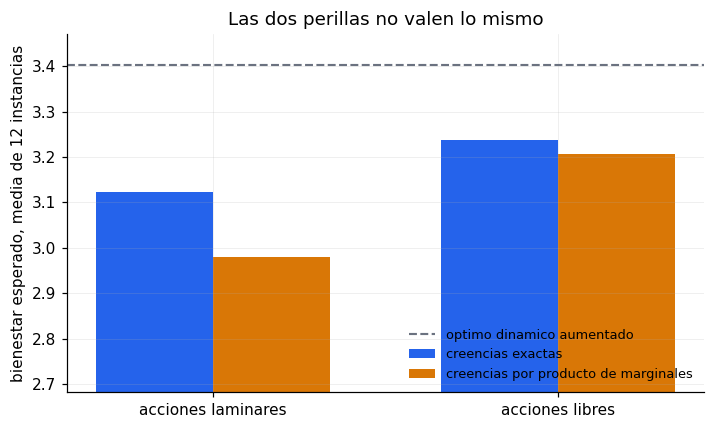

In [21]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
x, w = np.arange(2), 0.34
ax.bar(x - w / 2, [medias['exa_lam'], medias['exa_lib']], width=w,
       color=AZUL, label='creencias exactas')
ax.bar(x + w / 2, [medias['pro_lam'], medias['pro_lib']], width=w,
       color=AMBAR, label='creencias por producto de marginales')
ax.axhline(opt, color=GRIS, ls='--', lw=1.4, label='optimo dinamico aumentado')
ax.set_xticks(x)
ax.set_xticklabels(['acciones laminares', 'acciones libres'])
ax.set_ylabel('bienestar esperado, media de 12 instancias')
ax.set_ylim(0.9 * min(medias.values()), 1.02 * opt)
ax.set_title('Las dos perillas no valen lo mismo')
ax.legend(frameon=False, fontsize=8.5, loc='lower right')
fig.tight_layout()
plt.show()

**Lectura.** Las dos perillas no valen lo mismo y la diferencia es de casi cuatro
veces: soltar las acciones vale 3.68% y calcular bien vale 0.99%. La consecuencia
es incomoda y conviene decirla entera: la combinacion que el proyecto usa,
creencias exactas con acciones laminares, queda 2.60% por debajo de la ingenua,
producto de marginales con acciones libres.

R1 explica por que. El producto de marginales es exacto sobre pools disjuntos, asi
que solo se equivoca cuando la politica vuelve sobre territorio ya probado, y el
greedy no vuelve nunca. Calcular bien no puede pagarse con una politica que jamas
usa la informacion que el calculo preserva.

**Para discutir.** Si calcular bien vale poco porque el greedy no anida, entonces
el tensor no se paga con el greedy sino con las politicas que si anidan, que por
R1 son las optimas y por E4 el rollout. Conviene medir las dos perillas otra vez
sobre el rollout en vez del greedy?

## Donde queda todo

Los cinco experimentos atacan el objetivo goloso. E3 es el que mas mueve la aguja:
cierra la ruta directa a la garantia de 1 - 1/e bajo el mapeo pools-como-items y
deja el trabajo en las otras rutas que el plan mantiene abiertas, que son un
sustituto submodular, policy improvement, regret acotado, garantia por regimen o
certificado por instancia. E4 convierte un ejemplo suelto en una familia
con umbral exacto en p = 2 - raiz(2). E5 dejo de ser conjetura y tiene
demostracion, aunque el enunciado ya era del grupo.

Los tres bloqueadores son del paper, no del algoritmo. B1 estaba marcado como
pendiente en la auditoria de claims y aqui queda cerrado, y con un resultado mejor
del que se pedia: la adaptatividad sola vale cero en la familia, asi que toda la
separacion se le acredita al conteo. B2 es una decision editorial y ninguna de las dos opciones
pone el resultado en riesgo. B3 es el unico que puede hundir un envio, porque las
afirmaciones a escala descansan en un muestreador cuya correccion no esta
demostrada ni vigilada por la suite.

Queda un cuarto bloqueador que no tiene seccion porque no se puede verificar
corriendo codigo: la separacion sigue marcada como calificada en la auditoria. La
convencion ya no esta en discusion, porque el gate G0 congelo strict hard
clearing y la variante deductiva es otro modelo; lo que falta es reescribir el
enunciado publicado en esa convencion, con los numeros de B2.

Las dos ultimas secciones venian del plan del 27 de julio como B10' y B11', y
llevaban sin correrse desde entonces. R1 le pone mecanismo a E4: la brecha no esta
en elegir mejor el primer pool sino en volver sobre lo ya probado, algo que el
greedy no hace nunca. R2 mide por separado las dos perillas que siempre se habian
medido juntas, y el resultado obliga a replantear a quien se le cobra el tensor:
si calcular bien vale poco es porque el greedy no anida, asi que la inferencia
exacta se paga con las politicas que si anidan, no con el greedy.